## Install dependencies and import libraries

In [ ]:
!pip install -q torch torchvision

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

## Select device (CPU/GPU)

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


## Prepare STL10 dataset and dataloaders

In [3]:
# =====================================
# CELL 3: Dataset (STL10 + LAB)
# =====================================
from torchvision.datasets import STL10
from skimage.color import rgb2lab, lab2rgb

class ColorizationDataset(torch.utils.data.Dataset):
    def __init__(self, split='train', max_images=5000):
        self.dataset = STL10(
            root='./data',
            split=split,
            download=True,
            transform=transforms.Compose([
                transforms.Resize((128, 128)),
                transforms.ToTensor()
            ])
        )

        self.max_images = min(max_images, len(self.dataset))

    def __len__(self):
        return self.max_images

    def __getitem__(self, idx):
        img, _ = self.dataset[idx]
        img = img.permute(1, 2, 0).numpy()

        lab = rgb2lab(img).astype("float32")
        L = lab[:, :, 0] / 50.0 - 1.0
        ab = lab[:, :, 1:] / 128.0

        L = torch.tensor(L).unsqueeze(0)
        ab = torch.tensor(ab).permute(2, 0, 1)

        return L, ab

train_dataset = ColorizationDataset(split='train', max_images=5000)
val_dataset = ColorizationDataset(split='test', max_images=3000)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=32, num_workers=2, pin_memory=True)

print("Train size:", len(train_dataset))

100%|██████████| 2.64G/2.64G [01:07<00:00, 38.9MB/s]


Train size: 5000


## Define U-Net model and initialize weights

In [ ]:
# =====================================
# CELL 4: U-Net Model (Improved)
# =====================================
class UNet(nn.Module):
    def __init__(self):
        super().__init__()

        def block(in_c, out_c):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, 3, padding=1),
                nn.BatchNorm2d(out_c),
                nn.ReLU(inplace=True)
            )

        # Encoder
        self.enc1 = block(1, 64)
        self.enc2 = block(64, 128)
        self.enc3 = block(128, 256)

        self.pool = nn.MaxPool2d(2)

        # Bottleneck with dropout
        self.bottleneck = nn.Sequential(
            block(256, 512),
            nn.Dropout(0.3)
        )

        # Decoder
        self.up1 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.dec1 = block(512, 256)

        self.up2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec2 = block(256, 128)

        self.up3 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec3 = block(128, 64)

        # Output layer
        self.final = nn.Sequential(
            nn.Conv2d(64, 2, 1),
            nn.Tanh()
        )

    def forward(self, x):
        # Encoder
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))

        # Bottleneck
        b = self.bottleneck(self.pool(e3))

        # Decoder
        d1 = self.up1(b)
        d1 = torch.cat([d1, e3], dim=1)
        d1 = self.dec1(d1)

        d2 = self.up2(d1)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d3 = self.up3(d2)
        d3 = torch.cat([d3, e1], dim=1)
        d3 = self.dec3(d3)

        return self.final(d3)


# Initialize model
model = UNet().to(device)

# =====================================
# Weight Initialization
# =====================================
def init_weights(m):
    if isinstance(m, nn.Conv2d) or isinstance(m, nn.ConvTranspose2d):
        nn.init.kaiming_normal_(m.weight)

model.apply(init_weights)

print("Model initialized successfully!")

Model initialized successfully!


## Configure loss function and optimizer

In [5]:
l1_loss = nn.L1Loss()
mse_loss = nn.MSELoss()

def loss_fn(pred, target):
    return l1_loss(pred, target) + 0.1 * mse_loss(pred, target)

optimizer = optim.Adam(model.parameters(), lr=3e-4)

## Train model and save best checkpoint

In [6]:
# =====================================
# CELL 6: Training Loop (with best model saving)
# =====================================
epochs = 60

best_val_loss = float("inf")

for epoch in range(epochs):
    model.train()
    train_loss = 0

    for L, ab in train_loader:
        L, ab = L.to(device), ab.to(device)

        pred = model(L)
        loss = loss_fn(pred, ab)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    # Validation
    model.eval()
    val_loss = 0

    with torch.no_grad():
        for L, ab in val_loader:
            L, ab = L.to(device), ab.to(device)
            pred = model(L)
            val_loss += loss_fn(pred, ab).item()

    train_loss /= len(train_loader)
    val_loss /= len(val_loader)

    print(f"Epoch {epoch+1}/{epochs} | Train: {train_loss:.4f} | Val: {val_loss:.4f}")

    # Save BEST model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "best_model.pth")
        print("Best model saved!")

Epoch 1/60 | Train: 0.1064 | Val: 0.0765
Best model saved!
Epoch 2/60 | Train: 0.0726 | Val: 0.0715
Best model saved!
Epoch 3/60 | Train: 0.0703 | Val: 0.0720
Epoch 4/60 | Train: 0.0681 | Val: 0.0679
Best model saved!
Epoch 5/60 | Train: 0.0667 | Val: 0.0669
Best model saved!
Epoch 6/60 | Train: 0.0660 | Val: 0.0685
Epoch 7/60 | Train: 0.0652 | Val: 0.0652
Best model saved!
Epoch 8/60 | Train: 0.0648 | Val: 0.0652
Best model saved!
Epoch 9/60 | Train: 0.0642 | Val: 0.0647
Best model saved!
Epoch 10/60 | Train: 0.0638 | Val: 0.0659
Epoch 11/60 | Train: 0.0637 | Val: 0.0656
Epoch 12/60 | Train: 0.0635 | Val: 0.0649
Epoch 13/60 | Train: 0.0632 | Val: 0.0650
Epoch 14/60 | Train: 0.0629 | Val: 0.0646
Best model saved!
Epoch 15/60 | Train: 0.0628 | Val: 0.0659
Epoch 16/60 | Train: 0.0629 | Val: 0.0664
Epoch 17/60 | Train: 0.0624 | Val: 0.0634
Best model saved!
Epoch 18/60 | Train: 0.0625 | Val: 0.0641
Epoch 19/60 | Train: 0.0624 | Val: 0.0628
Best model saved!
Epoch 20/60 | Train: 0.0620 | V

## Load best checkpoint for evaluation

In [ ]:
# Load best model
model.load_state_dict(torch.load("best_model.pth"))
model.eval()

## Visualize predictions vs ground truth

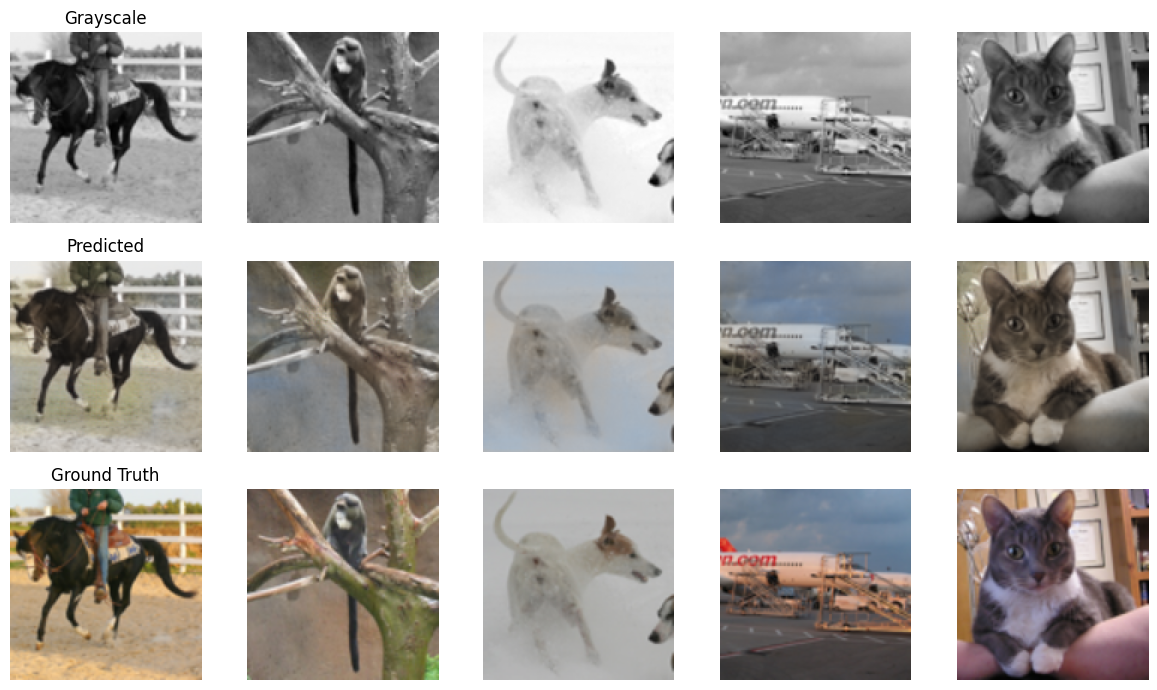

In [8]:
# =====================================
# CELL 7: Visualization
# =====================================
def show_results():
    model.eval()
    L, ab = next(iter(val_loader))

    L = L.to(device)

    with torch.no_grad():
        pred_ab = model(L).cpu()

    L = L.cpu()
    ab = ab.cpu()

    fig, axes = plt.subplots(3, 5, figsize=(12, 7))

    for i in range(5):
        # Predicted
        lab = torch.cat([L[i], pred_ab[i]], dim=0).permute(1,2,0).numpy()
        lab[:, :, 0] = (lab[:, :, 0] + 1.0) * 50.0
        lab[:, :, 1:] = lab[:, :, 1:] * 128.0
        rgb = lab2rgb(lab)

        # Ground truth
        real_lab = torch.cat([L[i], ab[i]], dim=0).permute(1,2,0).numpy()
        real_lab[:, :, 0] = (real_lab[:, :, 0] + 1.0) * 50.0
        real_lab[:, :, 1:] = real_lab[:, :, 1:] * 128.0
        real_rgb = lab2rgb(real_lab)

        axes[0, i].imshow(L[i][0], cmap='gray')
        axes[1, i].imshow(rgb)
        axes[2, i].imshow(real_rgb)

        axes[0, i].axis('off')
        axes[1, i].axis('off')
        axes[2, i].axis('off')

    axes[0, 0].set_title("Grayscale")
    axes[1, 0].set_title("Predicted")
    axes[2, 0].set_title("Ground Truth")

    plt.tight_layout()
    plt.show()

show_results()